# Advanced SQL

Alex Ronczewski  
2026-07-23

## Outline

### Prerequisites

-   Notebook 2 of this stream: joins, `GROUP BY`, `HAVING`, NULL,
    `CASE`.
-   Comfort with `pandas` and basic Python at the COMET-intermediate
    level

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Nest a query inside another query as a **derived table**, name query
    steps with **CTEs** (`WITH`), save whole queries as **views**, and
    choose between the three options by how long the query needs to
    live.
2.  Use **window functions** (`RANK`, aggregates with `OVER`) to rank
    within groups and build running totals, all without collapsing rows.
3.  Modify data with **INSERT**, **UPDATE**, and **DELETE**.
4.  Run SQL from Python with **parameterized queries**, and explain what
    a SQL injection is.

## 1. Where we are in the stream

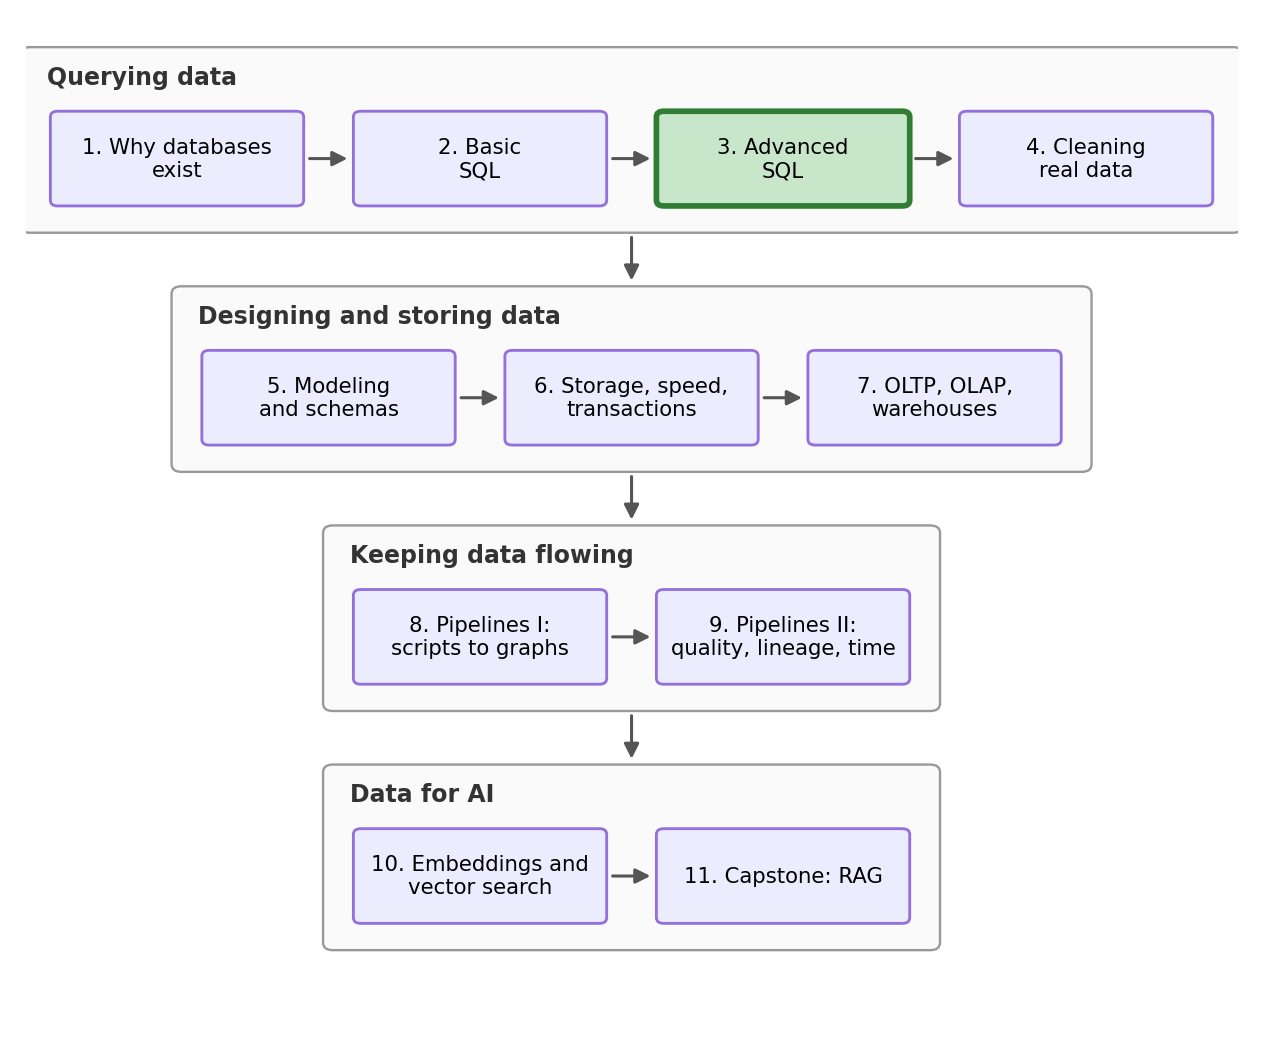

The dataframe from Notebook 2 was sent to your co-workers, and word
about your skills got around. You are now the research team’s SQL
person, and being the main SQL person means having a queue of tickets
everyday (but you also get a raise!). This morning it holds six tickets:
an old issue from the result of NB2, a scheduling request from the whole
team, two analysis asks, three admin items from the survey office, and a
teammate’s code waiting for review. Every single one needs a tool we do
not have yet, and together those tools are the second half of SQL, the
half that separates “knows a bit of SQL” from “uses it daily at work”.

## 2. Setup

We import our libraries and rebuild the database from the raw files, so
this notebook can be run alone (without needing to run NB1 or NB2):

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
provinces = pd.read_csv("datasets/provinces.csv")
certifications = pd.read_csv("datasets/certifications.csv")

conn = sqlite3.connect("datasets/wage_survey.db")
pd.read_csv("datasets/wage_survey.csv").to_sql("survey", conn, index=False, if_exists="replace")
provinces.to_sql("provinces", conn, index=False, if_exists="replace")
certifications.to_sql("certifications", conn, index=False, if_exists="replace")

684

In [3]:
%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.displaycon = False
%config SqlMagic.feedback = 0
%sql sqlite:///datasets/wage_survey.db

## 3. Ticket one: a query inside a query

> **Ticket #1, from the research lead.** “Before anything else: the
> certified wage. We shipped 39.89 knowing the grain was wrong. I want
> the real number.”

Joining `survey` to `certifications` counts every multi-certificate
person once per certificate, so the 39.89 average is computed on the
wrong grain. We even described the fix in Notebook 2: first collapse the
join to one row per person, then average the result. That is a query
running on the output of another query, and SQL lets you do that. A
query wrapped in parentheses inside the `FROM` clause is called a
**derived table**: its output rows become the input table for the outer
query, as if they had been in the database from the beginning.

In [4]:
%%sql
SELECT COUNT(*) AS certified_people, AVG(hourly_wage) AS avg_wage_certified
FROM (
    SELECT DISTINCT s.respondent_id, s.hourly_wage
    FROM survey AS s
    JOIN certifications AS c ON s.respondent_id = c.respondent_id
)

The inner query is Notebook 2’s join with `DISTINCT` collapsing it to
one row per certified person; the outer query counts and averages those
rows. 452 people, like before, but the true average is **39.44**, not
39.89. The wrong grain was inflating the answer by 45 cents, and against
the survey-wide average of 38.59 the real certified premium is about 85
cents an hour. Ticket closed! Good work.

Before finishing with the ticket, let’s quickly check again to make sure
it’s correct. Understanding it means reading inside-out, innermost
parentheses first, and if you open it again after a month you will find
yourself quite lost. SQL’s fix is the **CTE** (common table expression),
written with `WITH`: it gives a subquery a name at the **top** of the
query, and the rest of the query uses that name like a table. Same
logic, far better reading order:

In [5]:
%%sql
WITH per_person AS (
    SELECT DISTINCT s.respondent_id, s.hourly_wage
    FROM survey AS s
    JOIN certifications AS c ON s.respondent_id = c.respondent_id
)
SELECT COUNT(*) AS certified_people, AVG(hourly_wage) AS avg_wage_certified
FROM per_person

Read it top to bottom: first build `per_person`, then summarize it. This
is the order you think and speak in, so structuring the query like this
helps in readability, and `WITH` can take several named steps separated
by commas when the logic grows. This is the version that goes in the
reply to the research lead.

## 4. Ticket two: queries that persist

> **Ticket #2, from the whole team.** “The regional briefing is great.
> Can we re-run it ourselves on Fridays, without bothering you?”

A CTE’s name lives for one query and vanishes, and this ticket wants
something else: a query that outlives the notebook. SQL’s answer is a
**view**. `CREATE VIEW name AS` followed by any `SELECT` stores the
query itself, permanently, inside the database file, and from then on
the name can be queried like a normal table. Its companion
`DROP VIEW IF EXISTS` deletes the view if there is one (and does nothing
if there is not), which makes the pair safe to re-run any number of
times:

In [6]:
%%sql
DROP VIEW IF EXISTS regional_briefing

In [7]:
%%sql
CREATE VIEW regional_briefing AS
SELECT p.region,
       COUNT(*) AS workers,
       ROUND(AVG(s.hourly_wage), 2) AS avg_wage,
       ROUND(AVG(s.union_member), 2) AS union_share
FROM survey AS s
LEFT JOIN provinces AS p ON s.province = p.province
WHERE s.weekly_hours >= 30
GROUP BY p.region
HAVING COUNT(*) >= 50
ORDER BY avg_wage DESC

Both cells print nothing, which is what we are expecting. `CREATE VIEW`
stores the query and returns no rows. That stored query is Notebook 2’s
entire deliverable, and re-running the briefing is now a one-line
command, for every teammate who opens this database file:

In [8]:
%%sql
SELECT * FROM regional_briefing

One thing to hold on to: a view stores the **query**, but not the
results. Every `SELECT` against it re-runs the briefing on whatever the
data looks like at that moment, which is exactly what the team wants on
Fridays. If they wanted a static output they could just re-use last
week’s result. This is powerful: if we get 10,000 new observations, we
can re-run the analysis with one line.

> **The naming ladder**
>
> A **subquery** is anonymous work inside a single query. A **CTE**
> names a step for the duration of one query, for readability and
> stacking. A **view** names a whole query forever, inside the database
> file, for everyone. Choose which to use by how long the query needs to
> live.

## 5. Tickets three and four: window functions

> **Ticket #3, from the comms team.** “We need the top three earners in
> each province”

This sounds routine until you try it with Notebook 2’s tools.
`GROUP BY province` collapses each province to one row, so we don’t get
the top three. `ORDER BY hourly_wage DESC LIMIT 3` keeps people but
ranks the whole country, three rows total across all provinces; this is
also bad. This exact gap is what **window functions** exist to fill:
they compute group-level facts, like a rank within a province, while
**keeping every row**.

<figure>
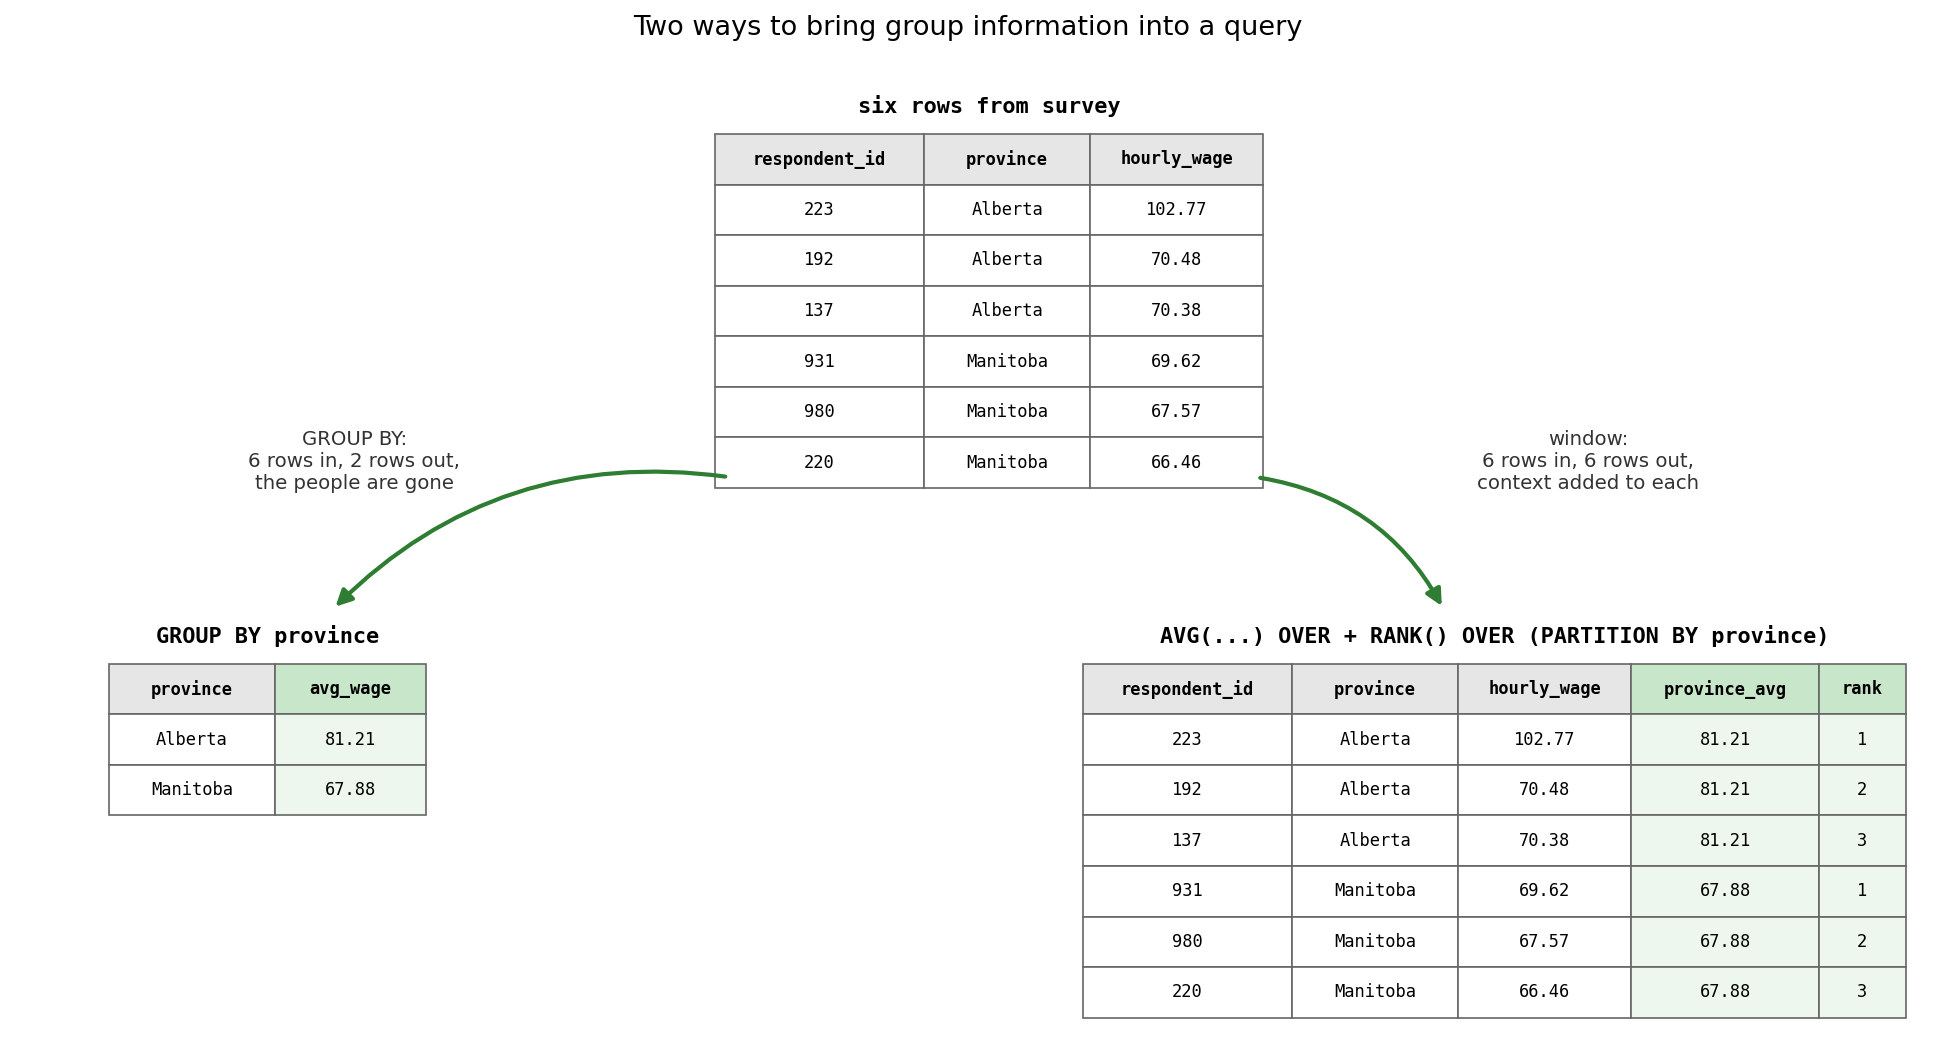
<figcaption aria-hidden="true">The same six rows, summarized two ways.
GROUP BY folds them into one row per group. A window function leaves all
six in place and writes the group context onto each of
them.</figcaption>
</figure>

The syntax reads like a sentence. `RANK()` assigns positions;
`OVER (...)` declares that it operates over a window of rows rather than
collapsing them; `PARTITION BY province` splits the rows into
per-province windows, the same role `GROUP BY` plays but without the
collapsing; `ORDER BY hourly_wage DESC` says what the rank orders. So
the ticket looks one `WHERE` away, rank inside each province, keep ranks
one to three:

In [9]:
%%sql
SELECT province, respondent_id, hourly_wage,
       RANK() OVER (PARTITION BY province ORDER BY hourly_wage DESC) AS province_rank
FROM survey
WHERE province_rank <= 3

RuntimeError: (sqlite3.OperationalError) misuse of aliased window function province_rank
[SQL: SELECT province, respondent_id, hourly_wage,
       RANK() OVER (PARTITION BY province ORDER BY hourly_wage DESC) AS province_rank
FROM survey
WHERE province_rank <= 3]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

SQLite refuses: `misuse of aliased window function`. You have already
seen an error just like this before, and it is Notebook 2’s evaluation
order: `WHERE` runs early, before the `SELECT` clause where the window
is computed, so at filtering time `province_rank` does not exist. To fix
this we use section 3’s tool. We compute the window inside a CTE, then
filter the CTE’s output, where the rank is a regular column:

In [10]:
%%sql
WITH ladders AS (
    SELECT province, respondent_id, hourly_wage,
           RANK() OVER (PARTITION BY province ORDER BY hourly_wage DESC) AS province_rank
    FROM survey
)
SELECT *
FROM ladders
WHERE province_rank <= 3
ORDER BY province, province_rank

Eighteen rows, three per province, every earner still exists as an
individual row. Ticket three ships to the comms team. Done!

> **Ticket #4, from the research lead.** “One chart for Thursday’s deck:
> how unequal are wages in our survey?”

One more window trick answers this. When the `OVER` clause contains an
`ORDER BY`, the window becomes cumulative: each row sees the rows up to
and including itself, which is how SQL does **running totals**. Sort
everyone by wage, accumulate the wages as you climb, divide by the
total, and you have built the cumulative wage distribution (the `<<`
arrow is Notebook 1’s trick, storing the result in a Python variable
named `lorenz` so we can plot it):

In [11]:
%%sql lorenz <<
WITH ordered AS (
    SELECT hourly_wage,
           SUM(hourly_wage) OVER (ORDER BY hourly_wage) AS running_total,
           RANK() OVER (ORDER BY hourly_wage) AS position
    FROM survey
)
SELECT position * 1.0 / (SELECT COUNT(*) FROM survey) AS worker_share,
       running_total / (SELECT SUM(hourly_wage) FROM survey) AS wage_share
FROM ordered
ORDER BY worker_share

Two details inside. The `* 1.0` exists because `position` and the row
count are whole numbers, and SQLite keeps whole-number division whole;
multiplying by 1.0 first forces the decimal shares we want. And the two
queries in parentheses are subqueries supplying the totals to divide by.

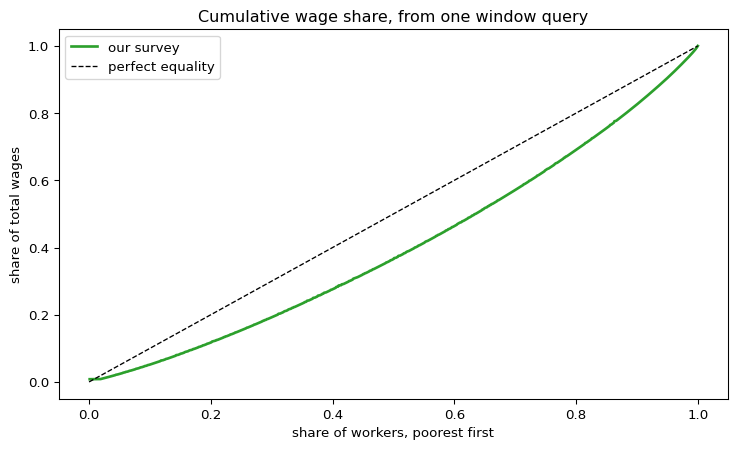

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(lorenz["worker_share"], lorenz["wage_share"], color="tab:green", linewidth=2, label="our survey")
plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1, label="perfect equality")
plt.xlabel("share of workers, poorest first")
plt.ylabel("share of total wages")
plt.title("Cumulative wage share, from one window query")
plt.legend()
plt.show()

The bottom half of earners take home about 37% of the wages. If the
curve hugged the dashed diagonal, every worker would earn the same; the
deeper it sags, the more unequal the distribution. Chart attached as an
email reply, ticket four closed!

## 6. Ticket five: INSERT, UPDATE, DELETE

> **Ticket #5, from the survey office.** “Two items: a late response to
> add, and respondent 731 has withdrawn consent, their data must be
> removed. Also a colleague of yours mentioned they were ‘fixing hours’
> in a practice table and now it looks wrong. Can you see what happened
> before they try it on the real one?”

Everything so far, across two and a half notebooks, has only ever
**read** the database. But late responses arrive, errors get corrected,
and people change their minds, so SQL has three writing commands:
`INSERT` (add rows), `UPDATE` (change values in existing rows), and
`DELETE` (remove rows). All three are irreversible unlike `SELECT`, so
professionals practice a discipline: **try destructive operations on a
copy first** and **make backups**. Let us make the same copy and
reconstruct what they did:

In [13]:
pd.read_sql("SELECT * FROM survey", conn).to_sql("survey_scratch", conn, index=False, if_exists="replace")

1000

We name the copy `survey_scratch`. And it has all 1,000 rows correctly
inside of it.

> **Wrong-query gallery #3**
>
> The colleague needed to correct respondent 404’s weekly hours to 40,
> wrote the `UPDATE`, saw “no error”, and only later felt that the
> numbers looked wrong. `UPDATE` names a table, `SET` assigns the new
> value:
>
> ``` python
> %%sql
> UPDATE survey_scratch
> SET weekly_hours = 40
> ```
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     |
> |-----|
>
> </div>
>
> ``` python
> %%sql
> SELECT ROUND(AVG(weekly_hours), 2) AS avg_hours, COUNT(DISTINCT weekly_hours) AS distinct_values
> FROM survey_scratch
> ```
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     | avg_hours | distinct_values |
> |-----|-----------|-----------------|
> | 0   | 40.0      | 1               |
>
> </div>
>
> One distinct value in the whole column: every one of a thousand
> respondents now works exactly 40 hours a week. What happened, and how
> do we prevent this from happening?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> The `UPDATE` has no `WHERE`, and an `UPDATE` without a `WHERE` applies
> to **every row**. One thousand values overwritten, no error, and we
> can’t undo it. The habit: write the `WHERE` as a `SELECT` first, check
> that it returns exactly the rows you intend, then convert it to the
> `UPDATE`. The corrected syntax:
>
> ``` python
> %%sql
> UPDATE survey_scratch
> SET weekly_hours = 40
> WHERE respondent_id = 404
> ```
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     |
> |-----|
>
> </div>
>
> One row targeted, one row changed.
>
> </details>

Now the office’s real table. The late response first: `INSERT INTO`
names the table and columns, `VALUES` supplies one row:

In [17]:
%%sql
INSERT INTO survey (respondent_id, age, gender, education, province, industry, union_member, weekly_hours, hourly_wage)
VALUES (1001, 27, 'Woman', 'College diploma', 'British Columbia', 'Hospitality', 0, 35.0, 36.10)

The `INSERT` itself prints nothing, so read the row back to confirm it
landed, with a subquery (section 5’s totals trick) reporting the new
table size in the same result:

In [18]:
%%sql
SELECT s.*, (SELECT COUNT(*) FROM survey) AS total_respondents
FROM survey AS s
WHERE s.respondent_id = 1001

One row, every value as submitted, and the total beside it reads 1,001.
Perfect.

Now the serious one: respondent 731 has withdrawn consent. We have to
address this, participation is voluntary, and the deletion must happen.
Look first, as always, then delete, then verify:

In [19]:
%%sql
SELECT respondent_id, age, province, industry FROM survey
WHERE respondent_id = 731

In [20]:
%%sql
DELETE FROM survey
WHERE respondent_id = 731

In [21]:
%%sql
SELECT COUNT(*) AS respondents FROM survey

The row is now correctly removed. The count reads exactly 1,000 again:
the insert took the table to 1,001, and the deletion brought it back.
Same count as this morning, yet a different thousand, since one person
left the study and one late respondent joined it. That is a living
database, and it is also why views store queries rather than results:
ask for `regional_briefing` now and it reports on today’s data, not on
the data from yesterday.

## 7. Ticket six: the lookup tool

> **Ticket #6, from a teammate.** “I wrote a little tool so the survey
> office can pull wages by province themselves, no SQL needed on their
> end. Can you check it before it ships?”

Real applications like a web form, dashboard, or chatbot, build queries
from **user input**. The teammate’s function, `wages_in`, takes a
province name typed by the survey office, wraps a query around it, and
returns the matching rows; the `print` inside shows the exact SQL it
built, which will matter in a moment. Look at how the query is
assembled: the input is pasted straight into the SQL string with an
f-string, the tempting, terrible and dangerous way. The cell defines the
function and test drives it on friendly input, where it works
flawlessly:

In [22]:
def wages_in(province):
    query = f"SELECT respondent_id, province, hourly_wage FROM survey WHERE province = '{province}'"
    print(query)
    return pd.read_sql(query, conn)

wages_in("Manitoba")

SELECT respondent_id, province, hourly_wage FROM survey WHERE province = 'Manitoba'

62 rows × 3 columns

62 Manitobans, as expected, and the printed query reads exactly like SQL
we would have written by hand.

> **Predict first.** The next cell calls the same function with the
> input `Nowhere' OR '1'='1`. Nowhere is not a province. How many rows
> come back?

In [23]:
wages_in("Nowhere' OR '1'='1")

SELECT respondent_id, province, hourly_wage FROM survey WHERE province = 'Nowhere' OR '1'='1'

1000 rows × 3 columns

All 1,000. Read the printed query: the input’s stray quote **ended the
province string early**, and everything after it became live SQL,
including a condition `'1'='1'` that is true for every row. Someone
typed text into a box, and the text rewrote the query’s logic. This is a
**SQL injection**. It has been a top web vulnerability for over two
decades, and versions of it have leaked entire customer databases.

Our attack only read data. An input with a more vicious ending deletes
it instead, which is the joke behind one of the most famous comics in
programming:

<figure>
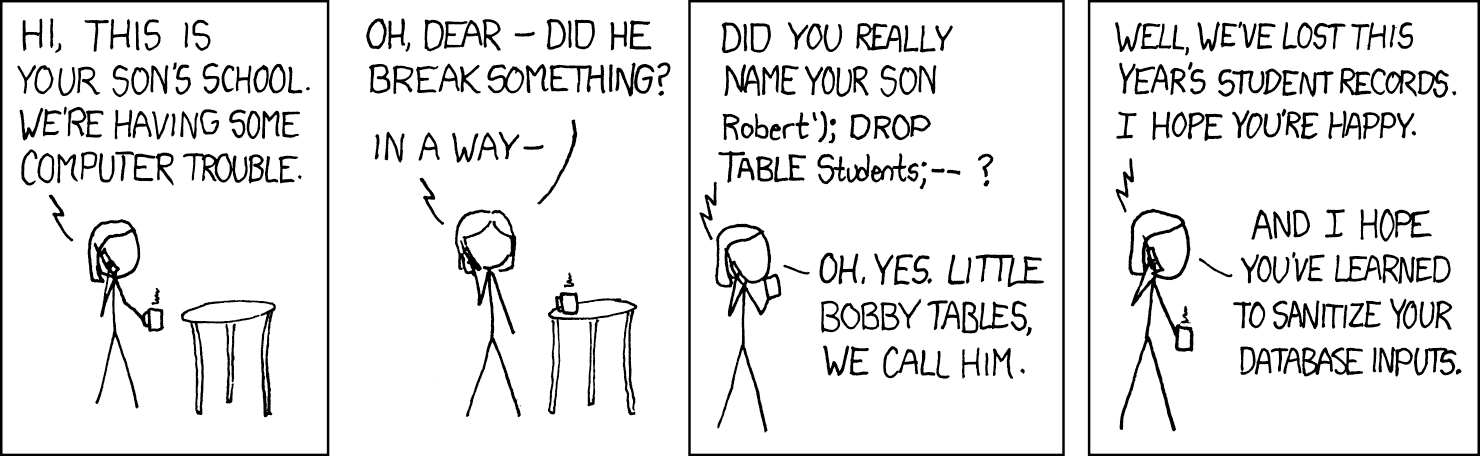
<figcaption aria-hidden="true">xkcd 327, “Exploits of a Mom”. The
school’s software pasted the student’s name straight into its SQL, the
name’s quote ended the string early, and
<code>DROP TABLE Students</code> ran as a live command. Our
<code>wages_in</code> has exactly this hole.</figcaption>
</figure>

The fix is simple: **SQL and data travel separately.** Every database
library accepts the query and the values as two different arguments,
with `?` marking where values go; `pd.read_sql` takes them through
`params`. The database then treats the input purely as a value, never as
SQL:

In [24]:
pd.read_sql("SELECT respondent_id, province, hourly_wage FROM survey WHERE province = ?",
            conn, params=("Nowhere' OR '1'='1",))

Zero rows: the entire attack string was compared, as an inert lump of
text, against province names, and matched nothing, while a legitimate
`params=("Manitoba",)` call returns the same 62 rows as before.

In [25]:
pd.read_sql("SELECT respondent_id, province, hourly_wage FROM survey WHERE province = ?",
            conn, params=("Manitoba",))

62 rows × 3 columns

We send the tool back to your teammate with two changed lines, and we
are done with our ticket queue and can take a well-deserved break!

## 8. Conclusion

Let’s look back at what the ticket queue taught you. A subquery fixed
Notebook 2’s final issue (the certified average is 39.44, an 85-cent
premium), a CTE made it readable, and a view turned the briefing into
permanent team infrastructure. Window functions answered the questions
`GROUP BY` cannot, ranks and running totals, and drew a Lorenz curve on
the way. INSERT, UPDATE, and DELETE made the database a living object,
with one near-catastrophe on the practice copy to show why the `WHERE`
clause is necessary. And one small habit, `?` plus `params`, fixed SQL
injections.

You are past the core of SQL now, and into the part that employers
specifically search for. The practice sites from Notebook 2 grade this
material as their medium tier; on DataLemur, the tags “Window Functions”
and “CTEs or Subquery” are yours to practice on.

> **You can now answer these interview questions**
>
> -   When would you use a subquery, a CTE, or a view?
> -   What is a window function, and how does it differ from `GROUP BY`?
> -   What happens to an `UPDATE` with no `WHERE` clause, and what habit
>     prevents it?
> -   Why are parameterized queries safer than building SQL strings from
>     input?
>
> <details>
>
> <summary>
>
> Show / hide model answers
>
> </summary>
>
> -   They are the same idea at three lifespans: a subquery is anonymous
>     and lives inside one query, a CTE names a step for the duration of
>     one query and makes multi-stage logic readable, and a view stores
>     the query permanently in the database for reuse by anyone.
> -   A window function computes over a group of related rows (declared
>     with `OVER`, optionally split by `PARTITION BY`) but keeps every
>     row, adding the group context as a new column, where `GROUP BY`
>     collapses each group to a single row.
> -   It updates every row in the table, silently and irreversibly.
>     Prevention: write the condition as a `SELECT` first, confirm
>     exactly which rows come back, then convert it to the `UPDATE`,
>     ideally after rehearsing on a copy.
> -   Parameters send the query and the values separately, so input is
>     only ever treated as a value. String-built SQL lets crafted input
>     escape its quotes and become executable SQL, which is a SQL
>     injection.
>
> </details>

## Appendix: the regression-ready table

One last build, pulling the whole arc together: the table you would
receive in COMET or econometrics class, one row per respondent, with the
outcome, the variables of interest, and the controls, assembled from all
our tables. A CTE gathers each person’s certification count; one new
function, `COALESCE`, which returns the first of its arguments that is
not NULL, turns the uncertified from NULL into an explicit 0. Finally a
view makes the result permanent:

In [26]:
%%sql
DROP VIEW IF EXISTS analysis_table

In [27]:
%%sql
CREATE VIEW analysis_table AS
WITH cert_counts AS (
    SELECT respondent_id, COUNT(*) AS certifications_held
    FROM certifications
    GROUP BY respondent_id
)
SELECT s.respondent_id, s.age, s.gender, s.education, s.industry,
       p.region, p.minimum_wage,
       CASE WHEN s.weekly_hours >= 30 THEN 1 ELSE 0 END AS full_time,
       COALESCE(c.certifications_held, 0) AS certifications_held,
       s.union_member, s.weekly_hours, s.hourly_wage
FROM survey AS s
LEFT JOIN provinces AS p ON s.province = p.province
LEFT JOIN cert_counts AS c ON s.respondent_id = c.respondent_id

In [28]:
%%sql
SELECT COUNT(*) AS rows,
       SUM(full_time) AS full_timers,
       SUM(CASE WHEN region IS NULL THEN 1 ELSE 0 END) AS missing_region,
       ROUND(AVG(certifications_held), 3) AS avg_certifications
FROM analysis_table

One thousand rows, one per respondent, with a full-time dummy, a
certification count averaging 0.684, and 46 rows where region is NULL
(our Saskatchewan respondents). This is the query you would email to a
co-author with the sentence “the analysis table is the view called
analysis_table”.

## Connections

-   **Back to [Notebook 2](notebook_02_basic_querying.qmd):** the
    certified-wage question that a single `SELECT` could not answer took
    one derived table, and the briefing you built there is now a view
    that outlives the notebook.
-   **Forward to [Notebook 4](notebook_04_cleaning_real_data.qmd):** a
    hand-maintained survey file arrives with every failure Notebook 1
    catalogued, and you clean it: entity resolution, string and date
    repair, outliers, imputation, and every fix as reproducible code.

### References

-   Malan, D. (2024). *CS50’s Introduction to Databases with SQL.*
    Harvard University. https://cs50.harvard.edu/sql/ (Lectures on
    relating and viewing cover subqueries and views.)
-   ThoughtSpot (formerly Mode). *SQL tutorial: advanced.*
    https://www.thoughtspot.com/sql-tutorial Window functions and
    subqueries with practice data.
-   Munroe, R. *Exploits of a mom.* xkcd 327. https://xkcd.com/327/ The
    Bobby Tables cartoon, section 7’s joke and its best mnemonic.
-   OWASP Foundation. *SQL injection.*
    https://owasp.org/www-community/attacks/SQL_Injection The standard
    reference on the attack and its defenses.
-   SQLite. *Window functions.*
    https://www.sqlite.org/windowfunctions.html The engine’s own
    documentation for section 5.
-   SQLite. *The WITH clause.* https://www.sqlite.org/lang_with.html
    CTEs, including recursive ones this stream leaves for another day.

------------------------------------------------------------------------